# Circular Waveguide Analysis

This notebook demonstrates a complete circular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.primitives import RectangularWaveguide, CircularWaveguide
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.circular_waveguide import CWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a circular waveguide with specified dimensions and mesh parameters.

In [2]:
# Waveguide parameters
radius = 150e-3  # Width: 100 mm
L = 300e-3  # Length: 200 mm
maxh = 0.04  # Mesh size

# Create waveguide geometry
cwg = CircularWaveguide(radius, L, maxh=maxh)
# save step file
cwg.save_step(r"./circular_waveguide.step")

print(f"Dimensions: radius={radius * 1e3:.0f}mm, L={cwg.length * 1e3:.0f}mm, L={L * 1e3:.0f}mm")
# print(f"Cutoff frequency (TE10): {cwg.cutoff_frequency_TE11 / 1e9:.3f} GHz")
print(f"Mesh DOFs: ~{cwg.mesh.nv} vertices")

cwg.show('mesh')
cwg.print_info()

Geometry saved to: circular_waveguide.step
Dimensions: radius=150mm, L=300mm, L=300mm
Mesh DOFs: ~391 vertices


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…


CircularWaveguide Geometry Information
Geometry type:          CircularWaveguide
Boundary condition:     wall
OCC geometry built:     True
Mesh generated:         True
  → Vertices:           391
  → Elements:           1,354
Detected ports:         2
  → port2, port1

Specific parameters:
  Radius:               0.150000 m
  Length:               0.300000 m


## 2. Analytical Solution

Compute the analytical Z-parameters for comparison with numerical results.


Structure Topology
Type: Single structure
Domains (1): ['vacuum']
Total Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']
CPU times: total: 15.6 ms
Wall time: 1.51 ms

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port2: circular (fit error: 0.0000)
	    R=0.150001
	  port1: circular (fit error: 0.0000)
	    R=0.150001
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
	port2 mode 0: TE_11 (cos), kc=12.2745, σ=-1
	port2 mode 1: TE_11 (sin), kc=12.2745, σ=-1
	port2 mode 2: TM_01, kc=16.0321, σ=-1
	port1 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port1 mode 1: TE_11 (sin), kc=12.2745, σ=+1
	port1 mode 2: TM_01, kc=16.0321, σ=+1
	------------------------------------------------------------
	Total modes: 6

--- 

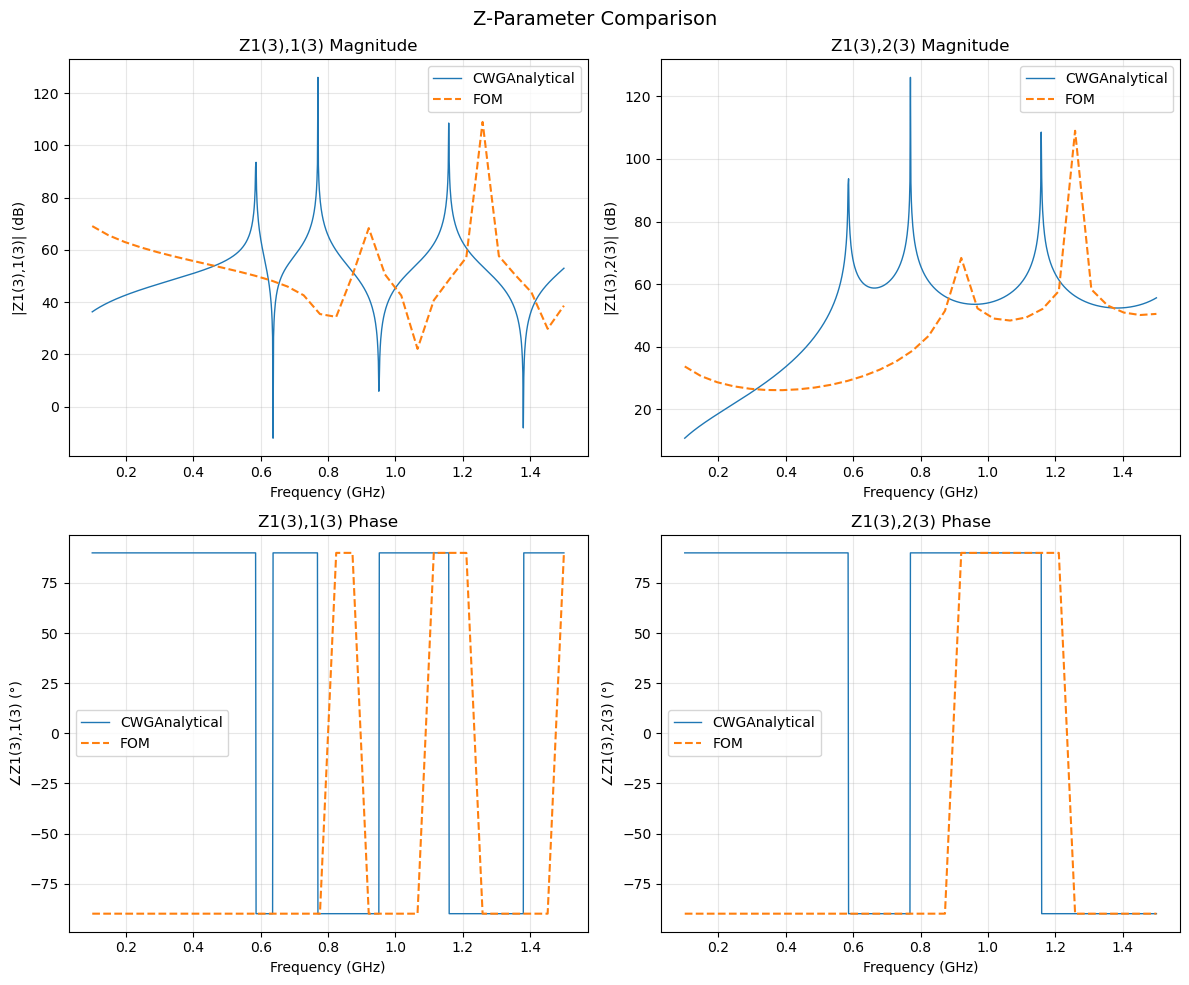

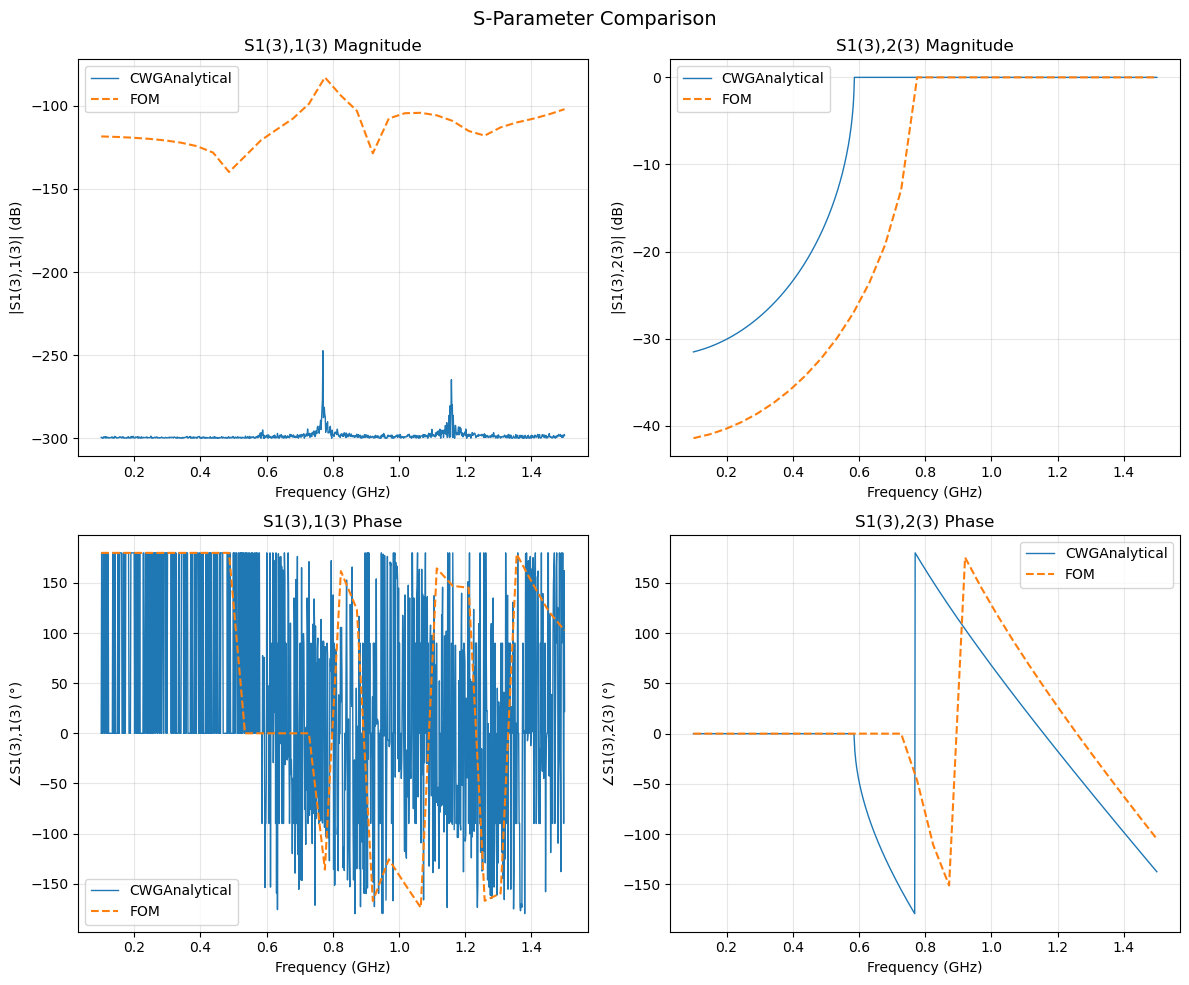

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(3),1(3)_mag': <Axes: title={'center': 'S1(3),1(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),1(3)| (dB)'>,
  'S1(3),1(3)_phase': <Axes: title={'center': 'S1(3),1(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),1(3) (°)'>,
  'S1(3),2(3)_mag': <Axes: title={'center': 'S1(3),2(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),2(3)| (dB)'>,
  'S1(3),2(3)_phase': <Axes: title={'center': 'S1(3),2(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),2(3) (°)'>})

In [3]:
# 2. Analytical
analytical = CWGAnalytical(radius=radius, length=L)

# 3. FOM solve
%time fds = FrequencyDomainSolver(cwg, order=3)
%time fds.assemble_matrices(nportmodes=3)
%time fds.solve(0.1, 1.5, 30, store_snapshots=True)

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(0.1, 1.5, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])
plot_s_comparison([analytical, fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])

In [4]:
fds.port_solver.print_info()


Port Eigenmode Solver Information
Mode source:          ANALYTIC
Polynomial order:     3
Dirichlet BC label:   wall
Polarization angle:   0.0°
Ensure inward power:  True
Global up direction:  [0. 1. 0.]
Propagation axis:     [0. 0. 1.]
Geometry tolerance:   0.0500

Number of detected/solved ports: 2
Total number of modes:           6

----------------------------------------------------------------------
Per-port summary:
----------------------------------------------------------------------
  port1:
    Geometry:       circular
    Fit error:      0.0000
    Radius:         R = 0.150001
    Area:           7.068642e-02
    Orientation σ:  +1
    Normal:         [ 0.  0. -1.]
    Modes found:    3
    Lowest fc:      0.5857 GHz
    Highest fc:     0.7649 GHz
    Modes (example):
      TE_11 (TE, 0.586 GHz (degen=2) pol=0°)
      TE_11 (TE, 0.586 GHz (degen=2) pol=90°)
      TM_01 (TM, 0.765 GHz pol=0°)

  port2:
    Geometry:       circular
    Fit error:      0.0000
    Radius:      

In [5]:
fds.plot_port_mode('port1', 1)


Port Mode: port1 [external (input)], Mode 1
Cutoff frequency: 0.5857 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [6]:
fds.plot_port_mode('port2', 1)


Port Mode: port2 [external (output)], Mode 1
Cutoff frequency: 0.5857 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [7]:
fds.plot_field(14)


Field visualization at f = 0.7759 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (None)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [8]:
# # 6. Eigenfrequency comparison
# fig, ax = plot_eigenfrequencies([fds], analytical=analytical, n_modes=50)
# ax.set_ylim(0.1, 5)
# ax.set_xlim(0.1, 5)


Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 37428
  Snapshots: 180
  Reduced DOFs: 30
  Compression: 99.9%
  Singular value decay: 2.48e+06 → 5.01e+00

------------------------------------------------------------
Total: 37428 → 30 DOFs
Overall compression: 99.9%


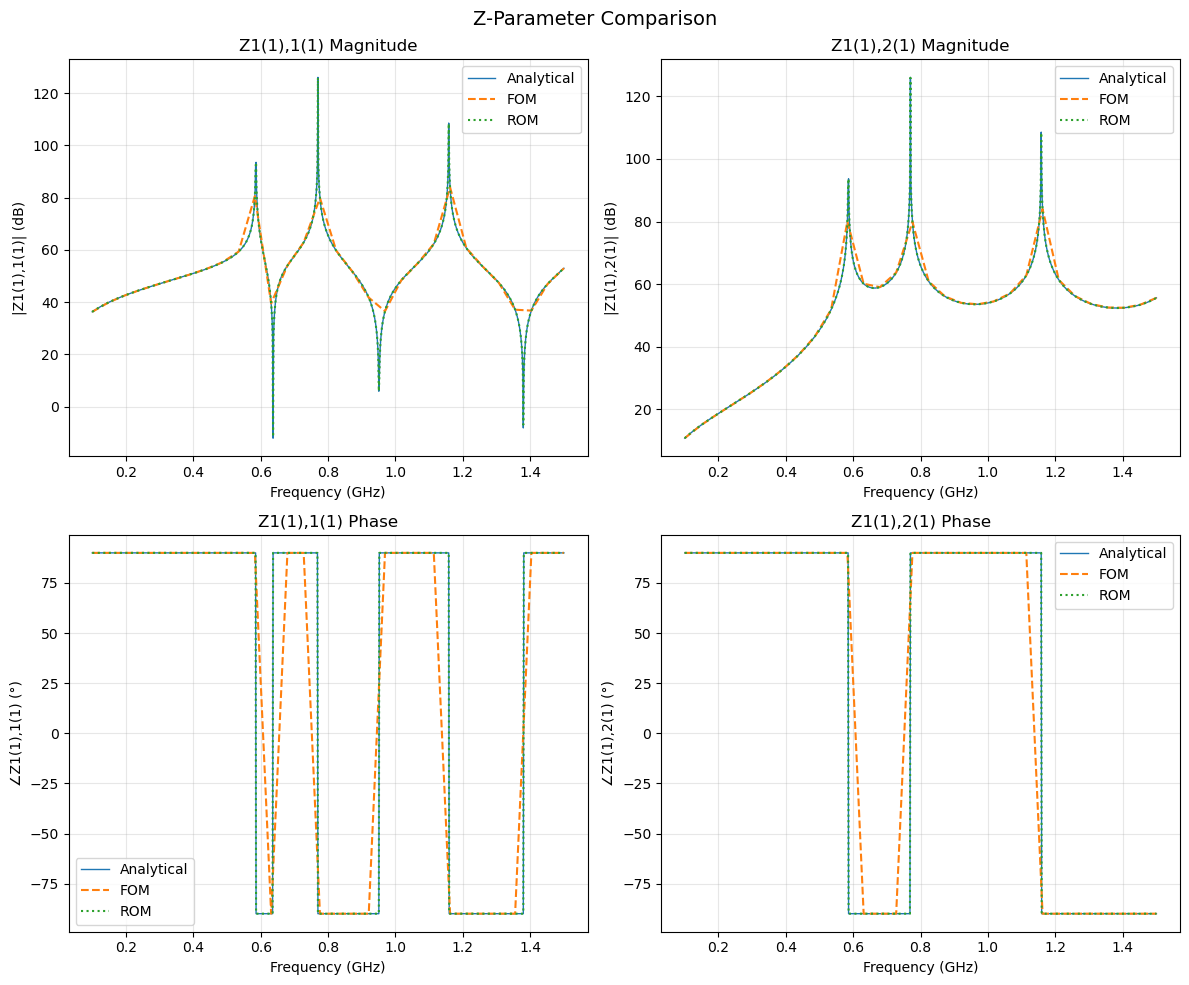

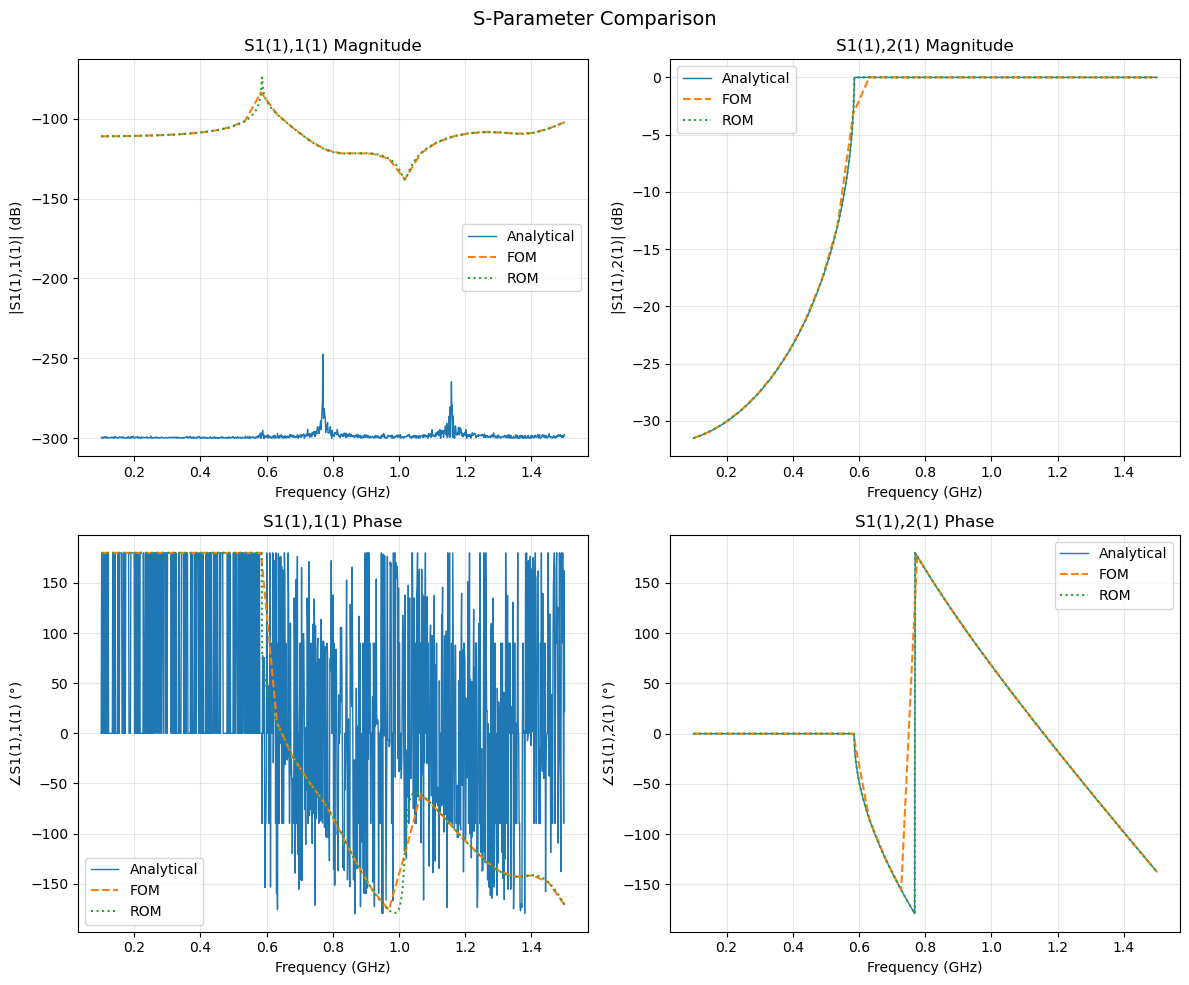

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [9]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

rom = ModelOrderReduction(fds)
rom.reduce(max_rank=30, tol=1e-6)
rom.solve(0.1, 1.5, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])


In [10]:
# fig, ax = plot_eigenfrequencies([fds, rom], analytical=analytical,
#                       labels=['FOM', 'ROM'], n_modes=50)
# ax.set_ylim(1, 5)
# ax.set_xlim(1, 5)

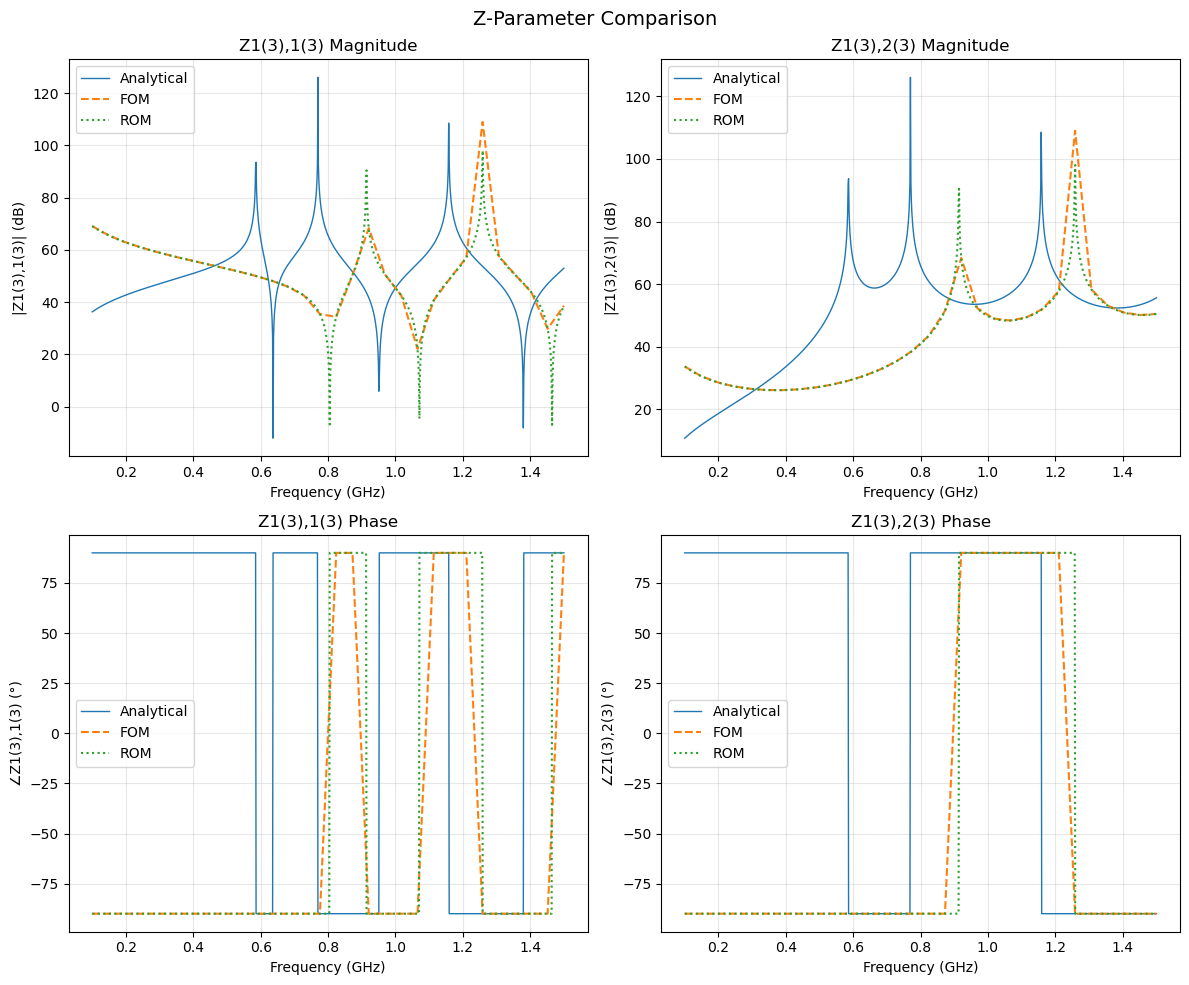

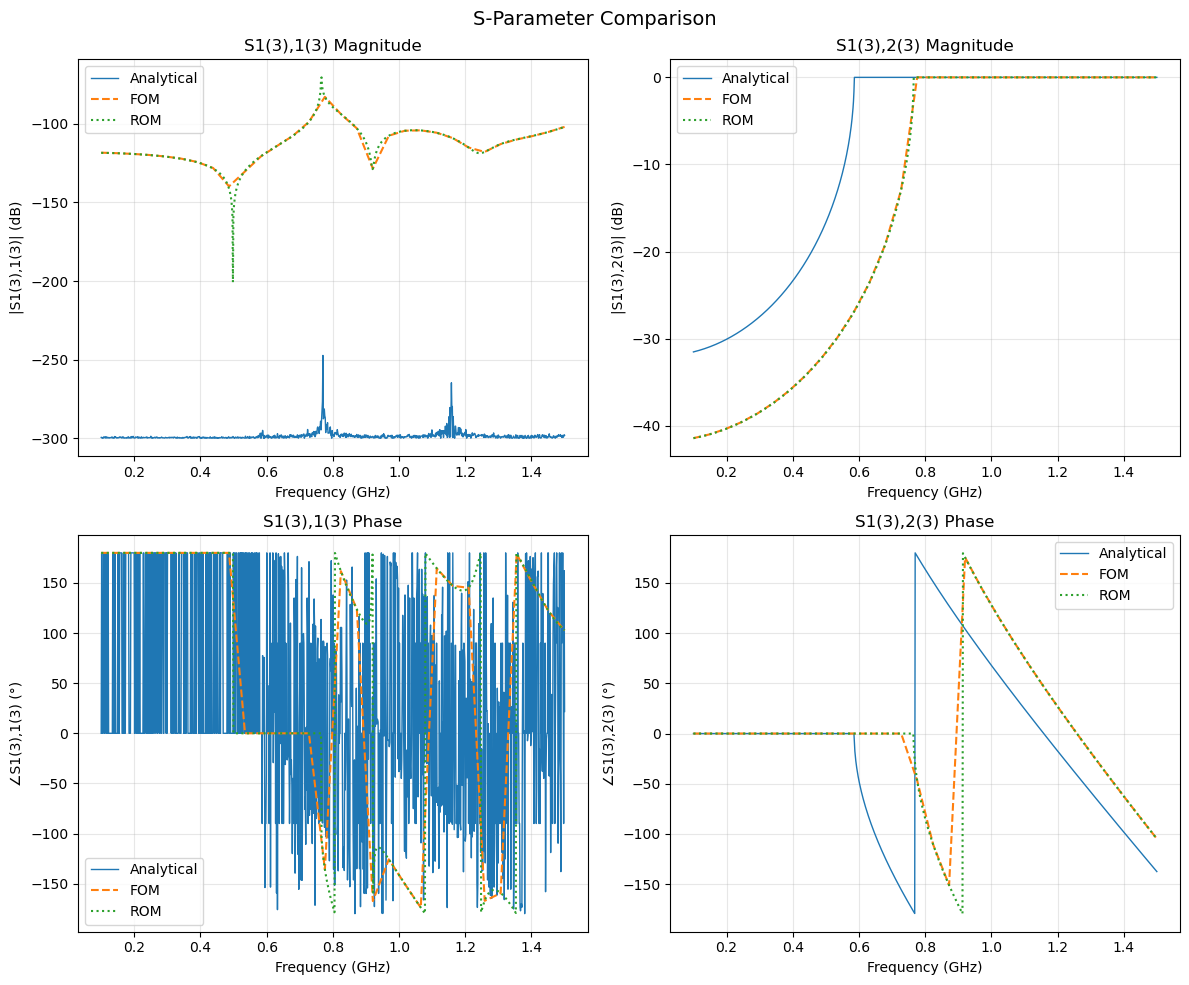

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(3),1(3)_mag': <Axes: title={'center': 'S1(3),1(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),1(3)| (dB)'>,
  'S1(3),1(3)_phase': <Axes: title={'center': 'S1(3),1(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),1(3) (°)'>,
  'S1(3),2(3)_mag': <Axes: title={'center': 'S1(3),2(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),2(3)| (dB)'>,
  'S1(3),2(3)_phase': <Axes: title={'center': 'S1(3),2(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),2(3) (°)'>})

In [11]:
# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'], mode_pairs=[(3, 3), (3, 3)])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'], mode_pairs=[(3, 3), (3, 3)])

In [12]:
ports = list(solver.port_modes.keys())
Zw_numerical = np.array([solver.port_solver.get_wave_impedance(ports[0], 0, f) for f in frequencies])
Zw_analytical = analytical.wave_impedance(frequencies)

# Plot
fig, ax = WaveImpedancePlotter.quick_plot(
    frequencies, Zw_analytical, Zw_numerical,
    cutoff_freq=analytical.fc,
    title='TE11 Wave Impedance'
)
plt.show()

NameError: name 'solver' is not defined

In [ ]:
# Singular value decay plot
fig2, ax2 = plt.subplots(figsize=(8, 5))

ConvergencePlotter.plot_singular_values(
    rom._singular_values,
    truncation_rank=rom.r,
    ax=ax2
)

plt.title('POD Singular Value Decay')
plt.tight_layout()
plt.show()

## 6. Error Analysis

Quantify the error between numerical solutions and the analytical reference.

In [ ]:
# ROM error
Z_ana_rom = analytical.z_parameters(Z_reduced['frequencies'])
Z11_rom = Z_reduced['Z'][:, 0, 0]
Z11_ana_rom = Z_ana_rom['Z11']

rel_error_rom = np.abs(Z11_rom - Z11_ana_rom) / np.abs(Z11_ana_rom)

print("ROM vs Analytical:")
print(f"   Mean relative error: {np.mean(rel_error_rom) * 100:.2f}%")
print(f"   Max relative error:  {np.max(rel_error_rom) * 100:.2f}%")

## 7. Eigenfrequency Comparison

Compare eigenfrequencies from the ROM with analytical values.

In [ ]:
# Get ROM eigenfrequencies
eigs_rom = rom.get_eigenvalues()
freqs_rom = np.sqrt(np.abs(eigs_rom)) / (2 * np.pi)
freqs_rom_ghz = freqs_rom / 1e9

print("ROM eigenfrequencies (GHz):")
for i, f in enumerate(sorted(freqs_rom_ghz)[:10]):
    print(f"   Mode {i + 1}: {f:.4f} GHz")

## Summary

This analysis demonstrated:
- **Geometry creation** for a rectangular waveguide
- **Full-order FEM** frequency domain analysis
- **Model order reduction** using POD with significant compression
- **Validation** against analytical solutions

The ROM provides accurate results with substantially reduced computational cost.

In [ ]:
# Optional: Save figures to files
# Uncomment to save

# fig.savefig('cwg_z_parameters.png', dpi=150, bbox_inches='tight')
# fig2.savefig('cwg_singular_values.png', dpi=150, bbox_inches='tight')
# print("Figures saved!")